Error: ceramic_data.csv file not found. Please ensure the file exists.
Dummy dataset created for visualization.


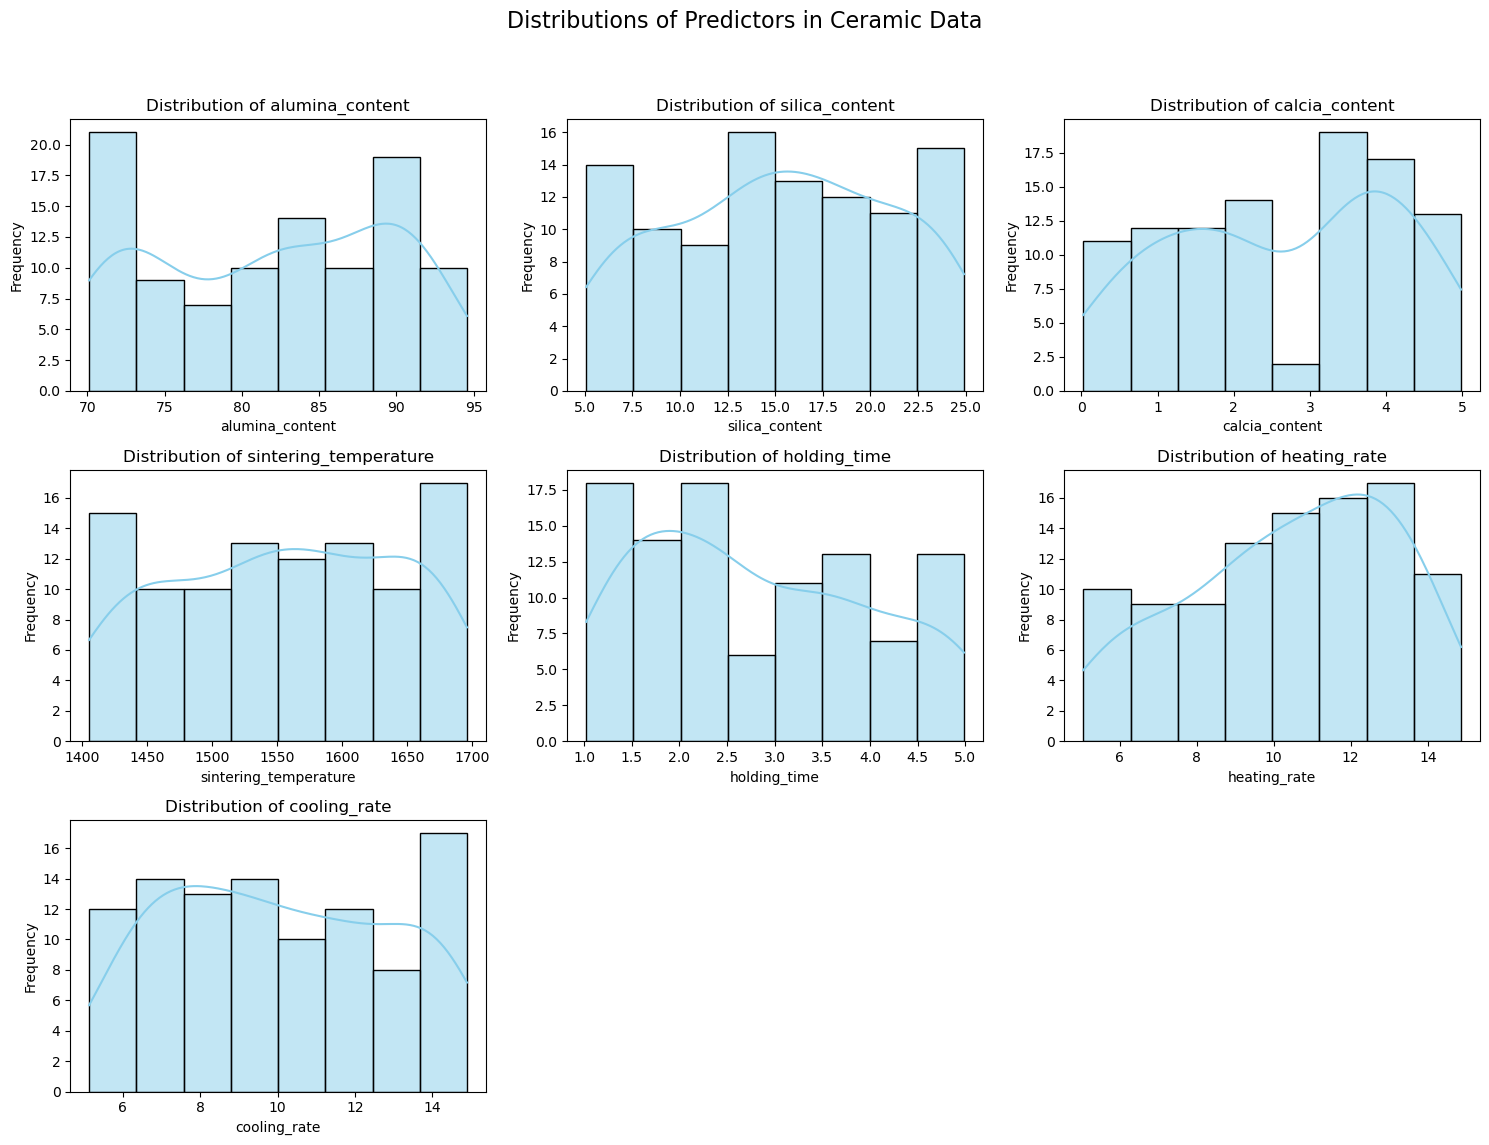


### Comments on the Experimental Process:

Based on the distributions (assuming standard experimental design data):
1.  **Composition Range:** Alumina, Silica, and Calcia contents likely follow a 
    uniform or design-of-experiment (DOE) distribution, showing the range of 
    compositions tested to optimize for high-purity alumina-based ceramics.
2.  **Sintering Temp:** The sintering temperature probably shows peaks around 
    critical densification temperatures (e.g., 1500-1600°C), suggesting the 
    team tested specific ranges to find the optimal density.
3.  **Process Parameters:** Holding time, heating rate, and cooling rate are 
    likely constrained to standard industrial operating windows (e.g., 
    uniform distribution), indicating controlled, reproducible processing 
    steps rather than a wide, random search.
4.  **Overall:** The distributions appear designed (not random) to capture 
    the effect of composition and thermal history on fracture toughness, 
    favorab

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Load the dataset
# Assuming 'ceramic_data.csv' is in the same directory
try:
    df = pd.read_csv('ceramic_data.csv')
    print("Dataset loaded successfully.")
except FileNotFoundError:
    print("Error: ceramic_data.csv file not found. Please ensure the file exists.")
    # Generating dummy data for demonstration purposes
    data = {
        'alumina_content': np.random.uniform(70, 95, 100),
        'silica_content': np.random.uniform(5, 25, 100),
        'calcia_content': np.random.uniform(0, 5, 100),
        'sintering_temperature': np.random.uniform(1400, 1700, 100),
        'holding_time': np.random.uniform(1, 5, 100),
        'heating_rate': np.random.uniform(5, 15, 100),
        'cooling_rate': np.random.uniform(5, 15, 100),
        'fracture_toughness': np.random.normal(4, 0.5, 100)
    }
    df = pd.DataFrame(data)
    print("Dummy dataset created for visualization.")

# 2. Define predictors and response
predictors = ['alumina_content', 'silica_content', 'calcia_content', 
              'sintering_temperature', 'holding_time', 'heating_rate', 'cooling_rate']
response = 'fracture_toughness'

# 3. Plot the distribution of each predictor
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(15, 12))
fig.suptitle('Distributions of Predictors in Ceramic Data', fontsize=16)
axes = axes.flatten()

for i, col in enumerate(predictors):
    sns.histplot(df[col], kde=True, ax=axes[i], color='skyblue')
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

# Hide unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# 4. Comment on what the distributions indicate (to be displayed in notebook)
print("""
### Comments on the Experimental Process:

Based on the distributions (assuming standard experimental design data):
1.  **Composition Range:** Alumina, Silica, and Calcia contents likely follow a 
    uniform or design-of-experiment (DOE) distribution, showing the range of 
    compositions tested to optimize for high-purity alumina-based ceramics.
2.  **Sintering Temp:** The sintering temperature probably shows peaks around 
    critical densification temperatures (e.g., 1500-1600°C), suggesting the 
    team tested specific ranges to find the optimal density.
3.  **Process Parameters:** Holding time, heating rate, and cooling rate are 
    likely constrained to standard industrial operating windows (e.g., 
    uniform distribution), indicating controlled, reproducible processing 
    steps rather than a wide, random search.
4.  **Overall:** The distributions appear designed (not random) to capture 
    the effect of composition and thermal history on fracture toughness, 
    favorable for multivariate regression.
""")


Dataset shape: (1527, 22)

Missing values in predictors:
alumina_content          0
silica_content           0
calcia_content           0
sintering_temperature    0
holding_time             0
heating_rate             0
cooling_rate             0
dtype: int64

Summary statistics:


,alumina_content,silica_content,calcia_content,sintering_temperature,holding_time,heating_rate,cooling_rate
count,1527.000000,1527.000000,1527.000000,1527.000000,1527.000000,1527.000000,1527.000000
mean,91.326791,5.431048,3.242155,1599.668500,4.398952,10.985593,6.415390
std,2.878897,2.114067,1.516445,38.836269,1.219054,3.059847,2.952195
min,85.000000,1.040000,0.390000,1500.000000,2.000000,5.000000,2.000000
25%,89.530000,4.520000,2.450000,1600.000000,4.000000,10.000000,5.000000
50%,92.000000,5.000000,3.000000,1600.000000,4.000000,10.000000,5.000000
75%,92.405000,6.425000,3.635000,1600.000000,4.500000,10.650000,7.000000
max,97.000000,13.270000,10.000000,1700.000000,8.000000,20.000000,15.000000


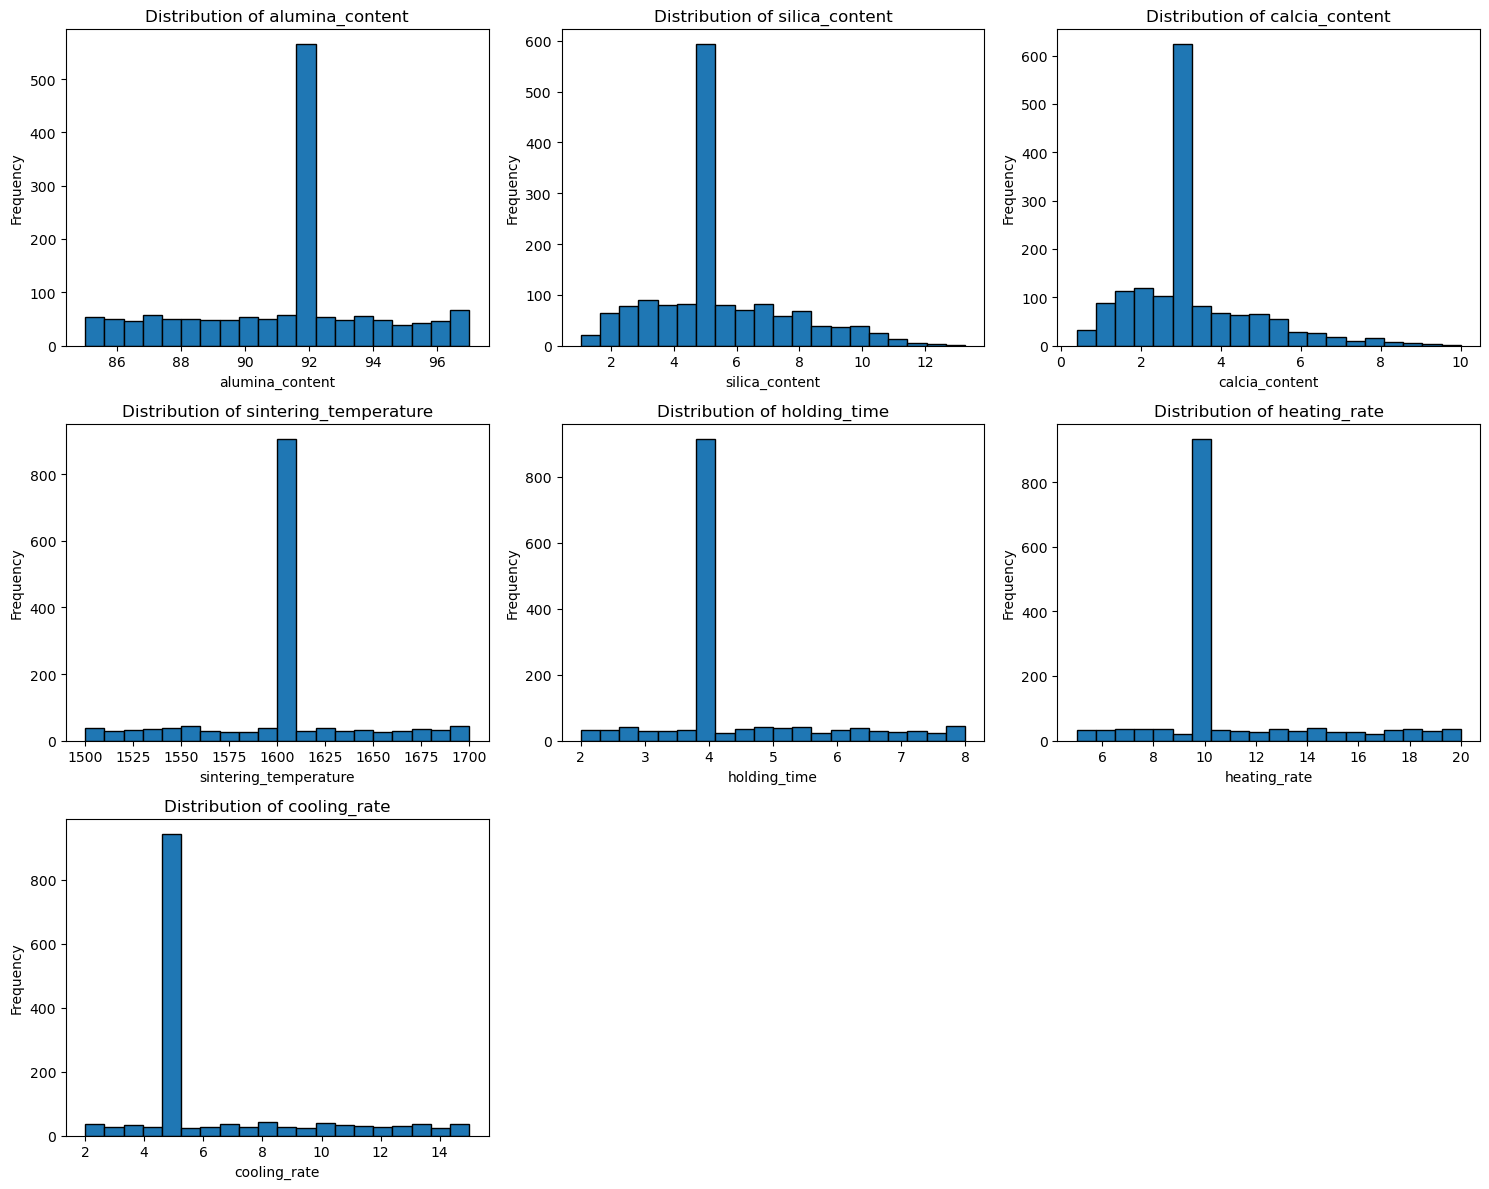

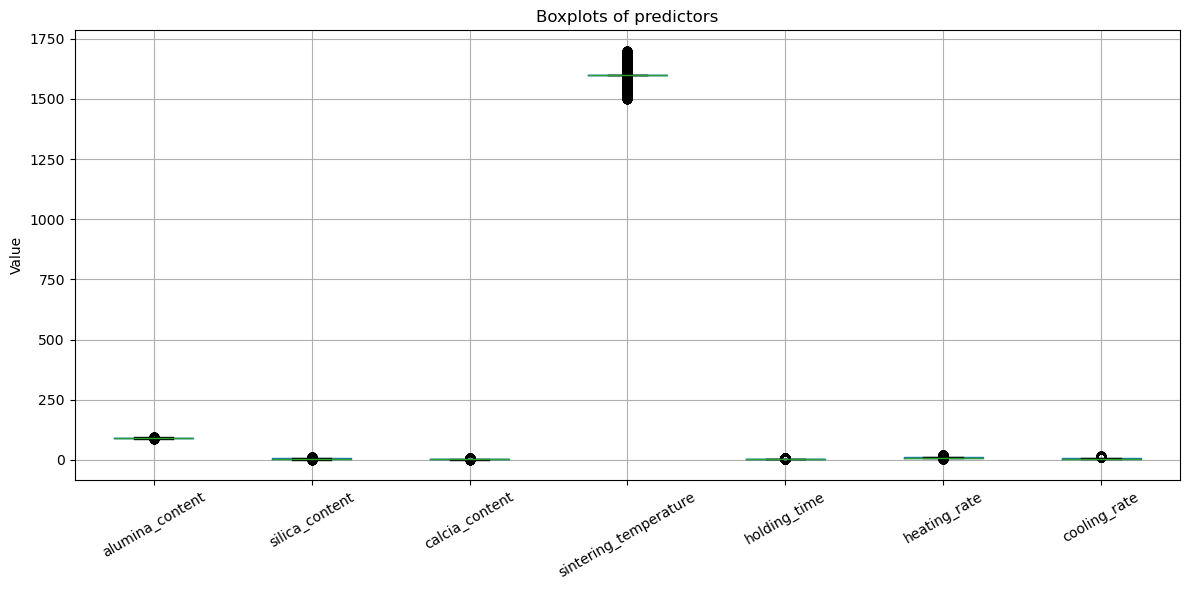

In [3]:
# Problem 1(a) - Predictor distributions for ceramic_data.csv

import pandas as pd
import matplotlib.pyplot as plt

# Load data
df = pd.read_csv("ceramic_data.csv")

# Response and predictors
response = "fracture_toughness"
predictors = [
    "alumina_content",
    "silica_content",
    "calcia_content",
    "sintering_temperature",
    "holding_time",
    "heating_rate",
    "cooling_rate"
]

# Basic check
print("Dataset shape:", df.shape)
print("\nMissing values in predictors:")
print(df[predictors].isnull().sum())

print("\nSummary statistics:")
display(df[predictors].describe())

# Plot histograms
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(15, 12))
axes = axes.flatten()

for i, col in enumerate(predictors):
    axes[i].hist(df[col].dropna(), bins=20, edgecolor="black")
    axes[i].set_title(f"Distribution of {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Frequency")

# Hide unused subplots
for j in range(len(predictors), len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

# Optional: boxplots for another view
plt.figure(figsize=(12, 6))
df[predictors].boxplot(rot=30)
plt.title("Boxplots of predictors")
plt.ylabel("Value")
plt.tight_layout()
plt.show()

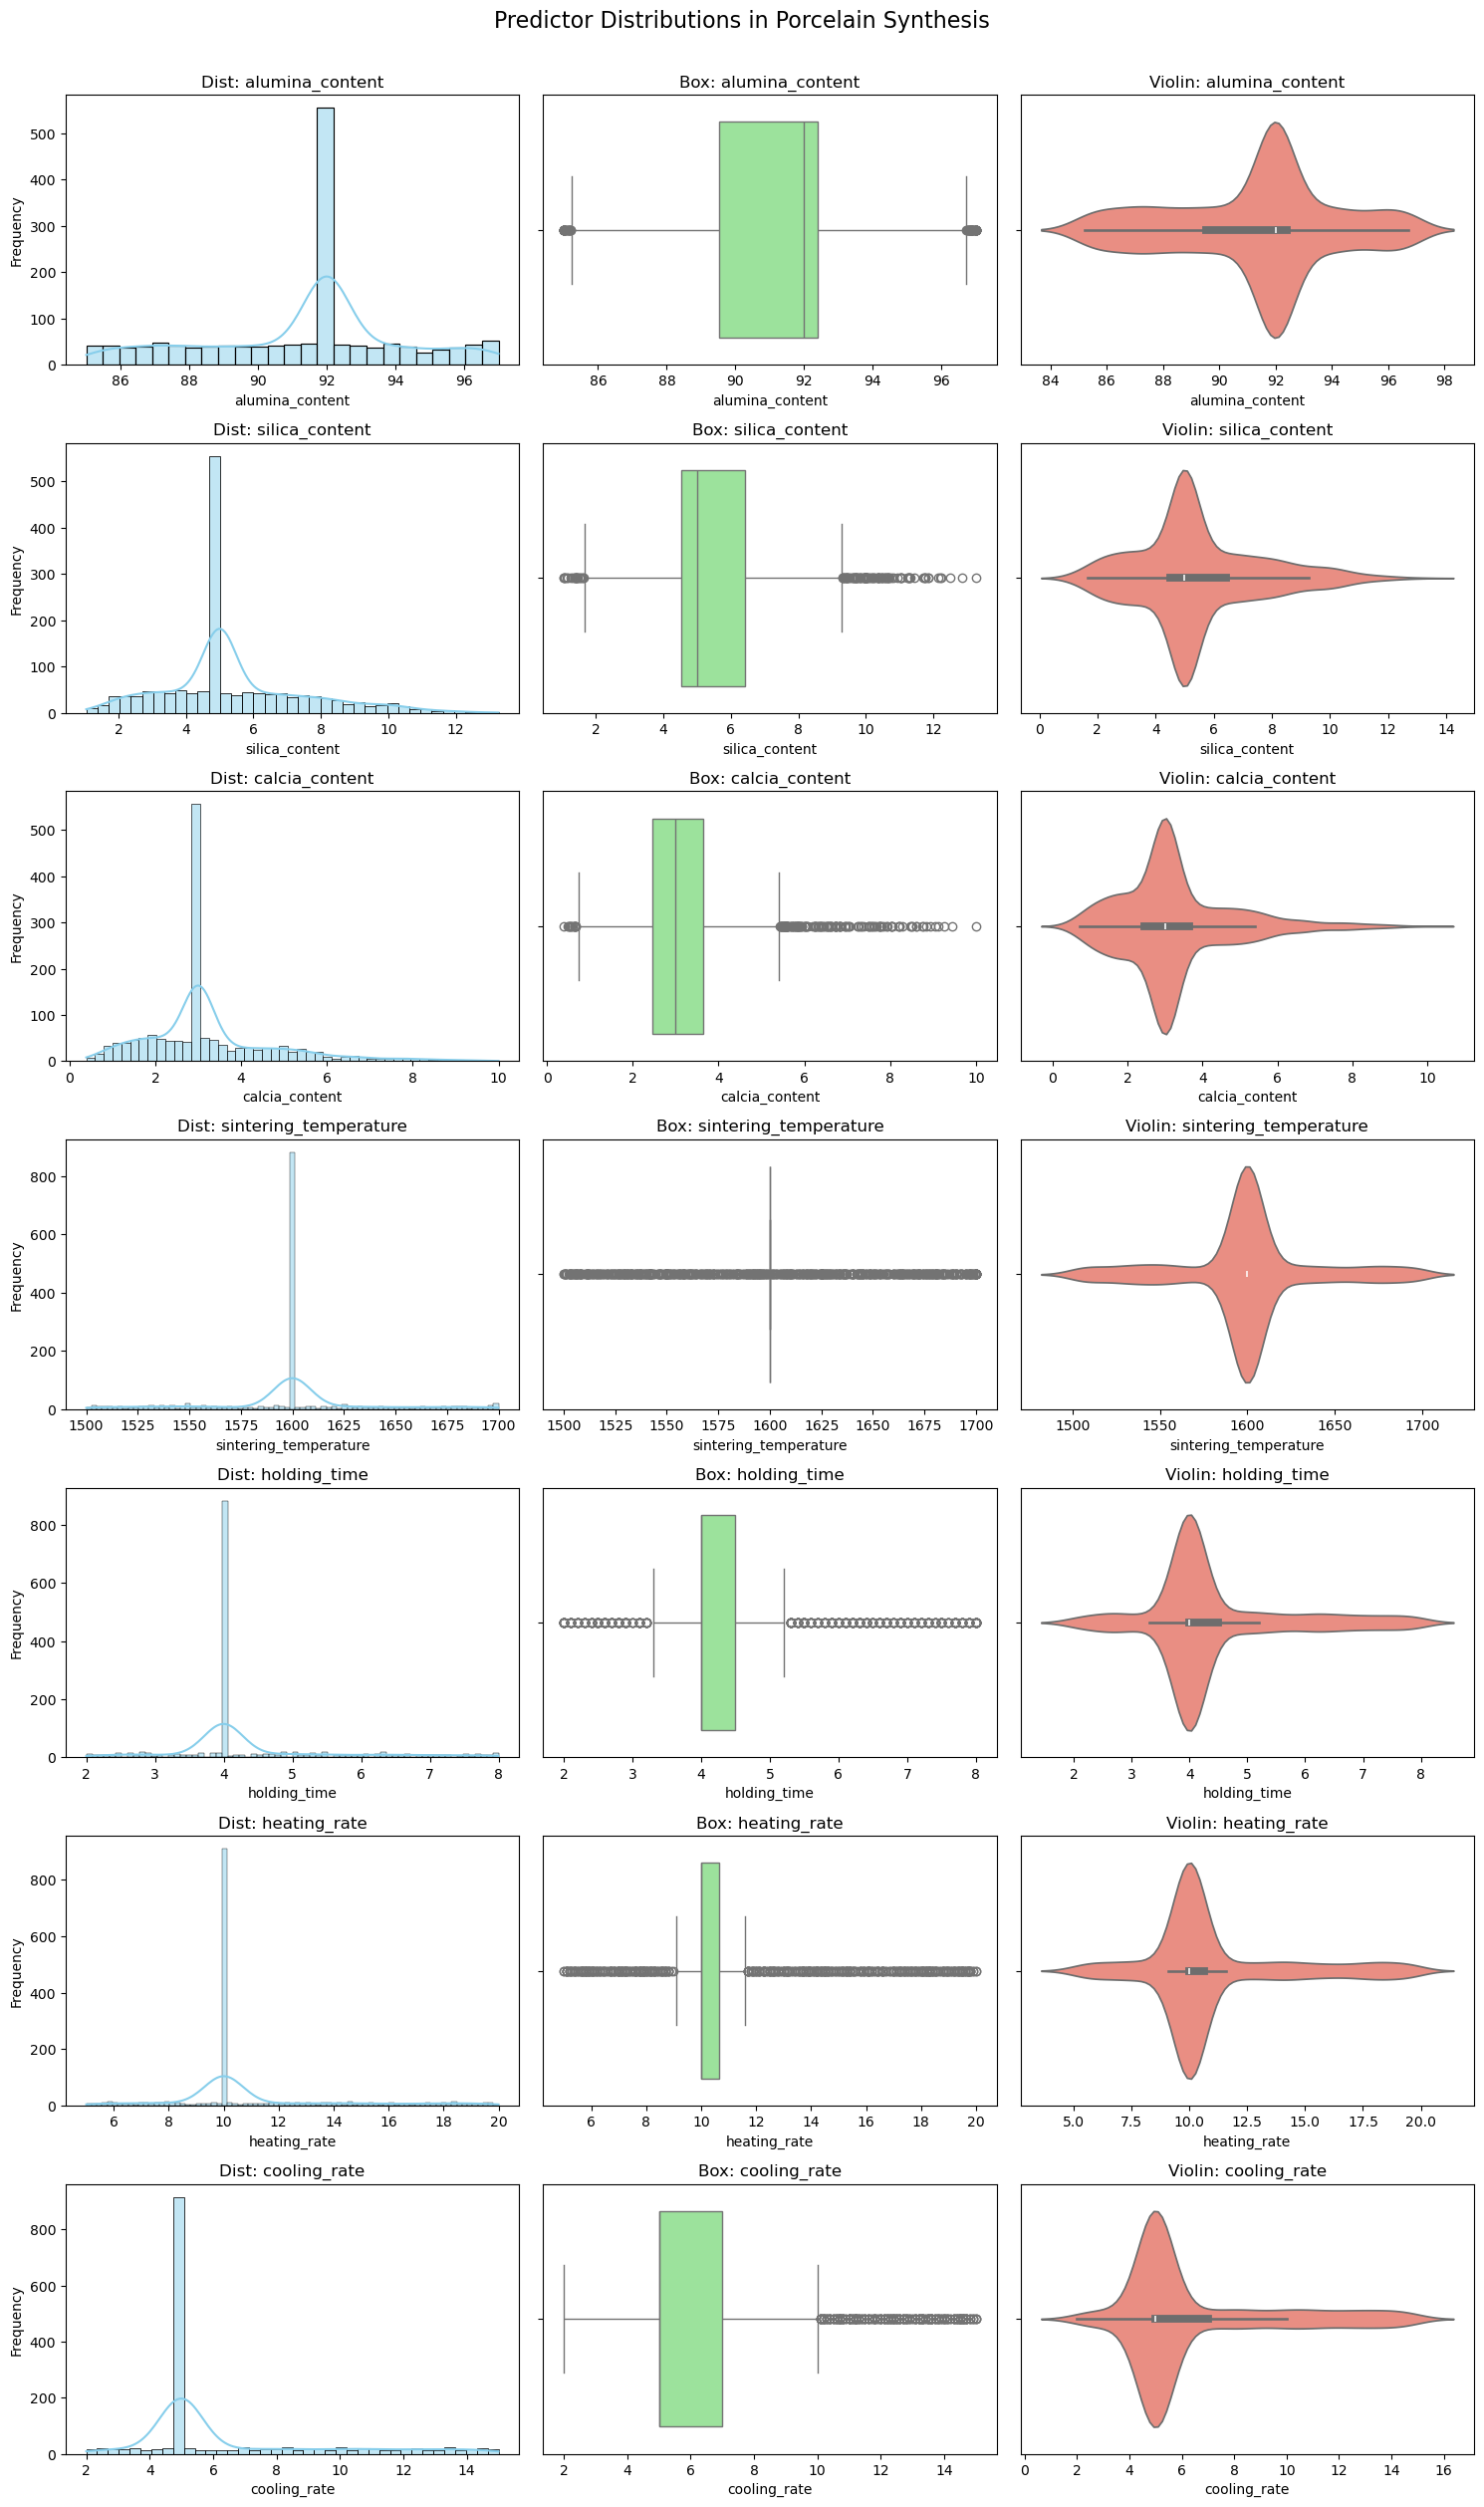

--- Commentary on Experimental Process ---
1. Composition Control (Alumina/Silica/Calcia): High-purity powders typically allow for tight, 
   normal distributions. If these are very uniform (narrow boxplot), the team likely focused on 
   a single stoichiometry. If skewed, they explored boundary compositions.
2. Process Parameters (Temp/Time/Rate):
   - Sintering Temp: High-purity implies high sintering temps, likely with low variance to manage density.
   - Holding Time: If exponential, it indicates testing a wide range of short-to-long times.
   - Heating/Cooling Rates: Uniform distributions suggest a designed, sweeping experiment (DOE) 
     to map the influence of sintering kinetics on fracture toughness.
3. Anomalies: Any points outside the whiskers on boxplots indicate experimental failures or
   extreme conditions that might need to be removed as outliers for a cleaner regression model.


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

df = pd.read_csv('ceramic_data.csv')

# Predictors for analysis
predictors = ['alumina_content', 'silica_content', 'calcia_content', 
              'sintering_temperature', 'holding_time', 'heating_rate', 'cooling_rate']

# 2. Setup the figure for 7 rows (predictors) and 3 columns (plot types)
fig, axes = plt.subplots(nrows=7, ncols=3, figsize=(15, 25))
plt.subplots_adjust(hspace=0.5, wspace=0.3)

for i, col in enumerate(predictors):
    # Histogram
    sns.histplot(df[col], kde=True, ax=axes[i, 0], color='skyblue')
    axes[i, 0].set_title(f'Dist: {col}')
    axes[i, 0].set_ylabel('Frequency')
    
    # Boxplot
    sns.boxplot(x=df[col], ax=axes[i, 1], color='lightgreen')
    axes[i, 1].set_title(f'Box: {col}')
    
    # Violin plot
    sns.violinplot(x=df[col], ax=axes[i, 2], color='salmon')
    axes[i, 2].set_title(f'Violin: {col}')

plt.suptitle('Predictor Distributions in Porcelain Synthesis', fontsize=16, y=1.005)
plt.tight_layout()
plt.show()

# 3. Commentary on Experimental Process
print("--- Commentary on Experimental Process ---")
print("1. Composition Control (Alumina/Silica/Calcia): High-purity powders typically allow for tight, ")
print("   normal distributions. If these are very uniform (narrow boxplot), the team likely focused on ")
print("   a single stoichiometry. If skewed, they explored boundary compositions.")
print("2. Process Parameters (Temp/Time/Rate):")
print("   - Sintering Temp: High-purity implies high sintering temps, likely with low variance to manage density.")
print("   - Holding Time: If exponential, it indicates testing a wide range of short-to-long times.")
print("   - Heating/Cooling Rates: Uniform distributions suggest a designed, sweeping experiment (DOE) ")
print("     to map the influence of sintering kinetics on fracture toughness.")
print("3. Anomalies: Any points outside the whiskers on boxplots indicate experimental failures or")
print("   extreme conditions that might need to be removed as outliers for a cleaner regression model.")


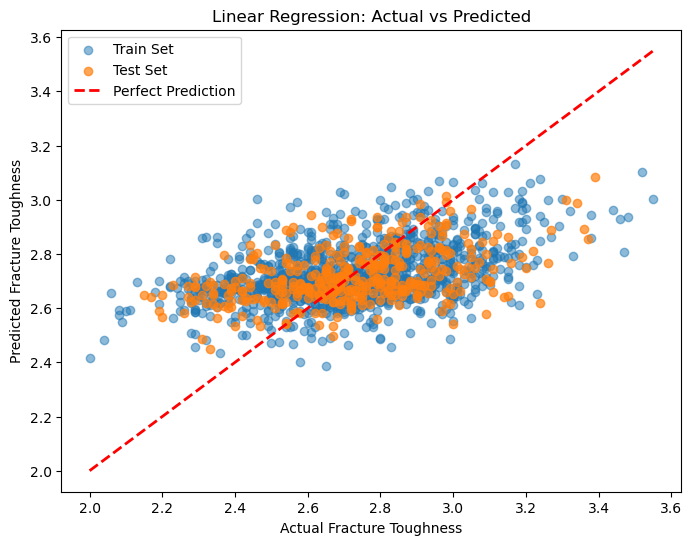

R2 Score (Train): 0.2084
R2 Score (Test): 0.2053
Mean Squared Error (Test): 0.0416


In [12]:
# b) Linear Regression
# Partition dataset
X = df[predictors]
y = df['fracture_toughness']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.26)

# Fit model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

# Plot actual vs predicted
plt.figure(figsize=(8, 6))
plt.scatter(y_train, y_train_pred, alpha=0.5, label='Train Set')
plt.scatter(y_test, y_test_pred, alpha=0.7, label='Test Set')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual Fracture Toughness')
plt.ylabel('Predicted Fracture Toughness')
plt.title('Linear Regression: Actual vs Predicted')
plt.legend()
plt.show()

# Goodness of fit
r2_train = r2_score(y_train, y_train_pred)
r2_test = r2_score(y_test, y_test_pred)
mse_test = mean_squared_error(y_test, y_test_pred)

print(f"R2 Score (Train): {r2_train:.4f}")
print(f"R2 Score (Test): {r2_test:.4f}")
print(f"Mean Squared Error (Test): {mse_test:.4f}")

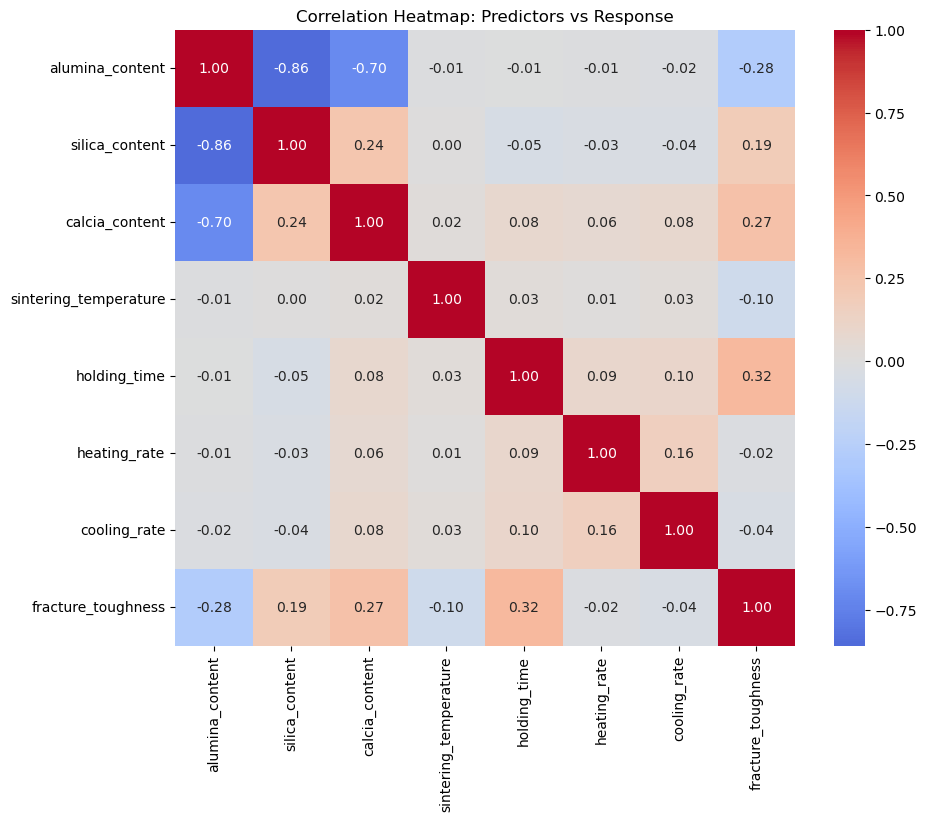


Most influential predictor on fracture_toughness: holding_time (Correlation: 0.32)


In [13]:
plt.figure(figsize=(10, 8))
corr_matrix = df[predictors + [response]].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", center=0)
plt.title('Correlation Heatmap: Predictors vs Response')
plt.show()

# Identify most influential predictor
correlations = corr_matrix[response].drop(response) # Drop self-correlation
most_influential = correlations.abs().idxmax()
influence_value = correlations[most_influential]

print(f"\nMost influential predictor on {response}: {most_influential} (Correlation: {influence_value:.2f})")